# Example of application to immune cells


We use the scanpy available PBMC 68k with labeled cell types from purified populations.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
base_colors = {
    "pbfi": "#277da1",
    "lrp": "#577590",
    "impacc": "#43aa8b",
    "split_cloc": "#f9c74f",
    "cloc": "#f8961e",
    "rampart": "#f94144",
    "perm": "#e377c2",
    "shapley": "#780000",
}
palette = list(base_colors.values())
sns.set_palette(palette)
palette = sns.color_palette(list(base_colors.values()))

In [2]:
adata = sc.datasets.pbmc68k_reduced()

In [3]:
adata

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [4]:
import sys
sys.path.append('../')
from clim import ClusterLOCOMP, ClusterLOCO_RAMPART, Cluster_LOCO_Split, hinge_error, GlobalStability_MP
from benchmarking import LRP_score, PBFI, c_SHAP, feature_imp_cluster, LOCO_silhouette
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from clim import BaseSpectralClustering
from sklearn.preprocessing import StandardScaler

## Choose clusterer

In [5]:
X = adata.X

In [6]:
K = len(adata.obs.bulk_labels.unique())

In [7]:
labels=pd.Categorical(adata.obs.bulk_labels).codes

In [14]:
# Compare KMeans vs SpectralClustering vs Agglomerative

# Choose clusterer based on generalizability
from sklearn.model_selection import train_test_split
X_tr, X_ca = train_test_split(X, test_size=0.5)
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import adjusted_rand_score
import tqdm
clf=RandomForestClassifier()
sp_gen, km_gen, ag_gen = [], [], []
for k in tqdm.tqdm(range(4, 12)):
    sp = FastSpectralClustering(n_clusters=k)
    ag = AgglomerativeClustering(n_clusters=k)
    km = KMeans(n_clusters=k)
    km_labels = km.fit_predict(X_tr)
    sp_labels = sp.fit_predict(X_tr)
    ag_labels = ag.fit_predict(X_tr)

    km_ca = clf.fit(X_tr, km_labels).predict(X_ca)
    sp_ca = clf.fit(X_tr, sp_labels).predict(X_ca)
    ag_ca = clf.fit(X_tr, ag_labels).predict(X_ca)

    km_ref = km.fit_predict(X_ca)
    sp_ref = sp.fit_predict(X_ca)
    ag_ref = ag.fit_predict(X_ca)

    km_gen.append(adjusted_rand_score(km_ca, km_ref))
    sp_gen.append(adjusted_rand_score(sp_ca, sp_ref))
    ag_gen.append(adjusted_rand_score(ag_ca, ag_ref))

100%|█████████████████████████████████████████████| 8/8 [00:09<00:00,  1.18s/it]


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch
# from your codebase:
# from ... import FastSpectralClustering

k_grid = np.arange(5, 16)
n_reps = 5

# shape: (n_reps, n_k)
km_gen = np.zeros((n_reps, len(k_grid)))
sp_gen = np.zeros((n_reps, len(k_grid)))
ag_gen = np.zeros((n_reps, len(k_grid)))
birch_gen = np.zeros((n_reps, len(k_grid)))
ag2_gen  = np.zeros((n_reps, len(k_grid)))

for rep in range(n_reps):
    X_tr, X_ca = train_test_split(X, test_size=0.5, random_state=rep)

    for j, k in enumerate(tqdm.tqdm(k_grid, desc=f"rep {rep+1}/{n_reps}")):
        km = KMeans(n_clusters=k, random_state=rep, n_init=10)
        ag = AgglomerativeClustering(n_clusters=k, linkage='ward')
        ag2 = AgglomerativeClustering(n_clusters=k, linkage='complete')
        birch = Birch(n_clusters=k)
        sp = FastSpectralClustering(n_clusters=k)  # add random_state=rep if supported

        # fit on training half
        km_labels = km.fit_predict(X_tr)
        sp_labels = sp.fit_predict(X_tr)
        ag_labels = ag.fit_predict(X_tr)
        ag2_labels = ag2.fit_predict(X_tr)
        birch_labels = birch.fit_predict(X_tr)

        # train classifier to transfer labels to calibration half
        km_clf = RandomForestClassifier(random_state=rep)
        sp_clf = RandomForestClassifier(random_state=rep)
        ag_clf = RandomForestClassifier(random_state=rep)
        ag2_clf = RandomForestClassifier(random_state=rep)
        birch_clf = RandomForestClassifier(random_state=rep)

        km_ca = km_clf.fit(X_tr, km_labels).predict(X_ca)
        sp_ca = sp_clf.fit(X_tr, sp_labels).predict(X_ca)
        ag_ca = ag_clf.fit(X_tr, ag_labels).predict(X_ca)
        ag2_ca = ag2_clf.fit(X_tr, ag2_labels).predict(X_ca)
        birch_ca = birch_clf.fit(X_tr, birch_labels).predict(X_ca)

        # reference clustering on calibration half
        km_ref = KMeans(n_clusters=k, random_state=rep, n_init=10).fit_predict(X_ca)
        sp_ref = FastSpectralClustering(n_clusters=k).fit_predict(X_ca)  # add random_state=rep if supported
        ag_ref = AgglomerativeClustering(n_clusters=k).fit_predict(X_ca)
        ag2_ref = AgglomerativeClustering(n_clusters=k).fit_predict(X_ca)
        birch_ref = Birch(n_clusters=k).fit_predict(X_ca)

        # generalizability score
        km_gen[rep, j] = adjusted_rand_score(km_ca, km_ref)
        sp_gen[rep, j] = adjusted_rand_score(sp_ca, sp_ref)
        ag_gen[rep, j] = adjusted_rand_score(ag_ca, ag_ref)
        ag2_gen[rep, j] = adjusted_rand_score(ag2_ca, ag2_ref)
        birch_gen[rep, j] = adjusted_rand_score(birch_ca, birch_ref)

# mean and SE across replicates
km_mean = km_gen.mean(axis=0)
sp_mean = sp_gen.mean(axis=0)
ag_mean = ag_gen.mean(axis=0)
ag2_mean = ag2_gen.mean(axis=0)
birch_mean = birch_gen.mean(axis=0)

km_se = km_gen.std(axis=0, ddof=1) / np.sqrt(n_reps)
sp_se = sp_gen.std(axis=0, ddof=1) / np.sqrt(n_reps)
ag_se = ag_gen.std(axis=0, ddof=1) / np.sqrt(n_reps)
ag2_se = ag2_gen.std(axis=0, ddof=1) / np.sqrt(n_reps)
birch_se = birch_gen.std(axis=0, ddof=1) / np.sqrt(n_reps)

rep 5/5: 100%|██████████████████████████████████| 11/11 [00:41<00:00,  3.79s/it]


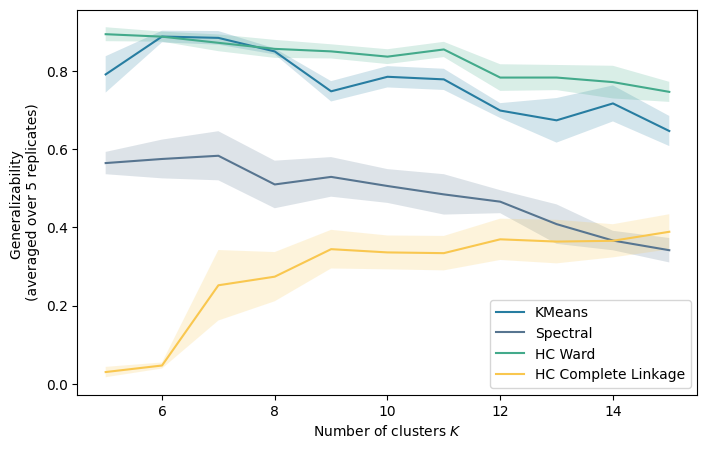

In [39]:
# plot mean with SE bands
plt.figure(figsize=(8, 5))

plt.plot(k_grid, km_mean, label="KMeans")
plt.fill_between(k_grid, km_mean - km_se, km_mean + km_se, alpha=0.2)

plt.plot(k_grid, sp_mean, label="Spectral")
plt.fill_between(k_grid, sp_mean - sp_se, sp_mean + sp_se, alpha=0.2)

plt.plot(k_grid, ag_mean, label="HC Ward")
plt.fill_between(k_grid, ag_mean - ag_se, ag_mean + ag_se, alpha=0.2)

plt.plot(k_grid, ag2_mean, label="HC Complete Linkage")
plt.fill_between(k_grid, ag2_mean - ag2_se, ag2_mean + ag2_se, alpha=0.2)

plt.xlabel(r"Number of clusters $K$")
plt.ylabel("Generalizability \n(averaged over 5 replicates)")
# plt.title("Averaged across 5 replicates")
plt.legend()
# plt.savefig('../figures/generalizability_pbmc68k.pdf', dpi=300)
plt.show()

Purified labels have $K=10$ classes, we choose HC with ward linkage as the best method for generalizability at $K=10$.

In [8]:
ag = AgglomerativeClustering(n_clusters=10)
ag_labels = ag.fit_predict(X)
km_labels = KMeans(n_clusters=10).fit_predict(X)
sp_labels = SpectralClustering(n_clusters=10).fit_predict(X)

In [12]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)

/var/folders/r4/_v5hj9j14b53twvkrltmh9vh0000gn/T/ipykernel_81340/1139750790.py:12: UserWarning: The palette list has more values (20) than needed (10), which may not be intended.
  sns.scatterplot(x=X_pca[:,0], y=X_pca[:, 1], hue=adata.obs['bulk_labels'], palette=palette, ax=ax[0], legend=False)
/var/folders/r4/_v5hj9j14b53twvkrltmh9vh0000gn/T/ipykernel_81340/1139750790.py:13: UserWarning: The palette list has more values (20) than needed (11), which may not be intended.
  sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, adata.obs['louvain'].values.astype(int).tolist()), palette=palette, ax=ax[1], legend=False)


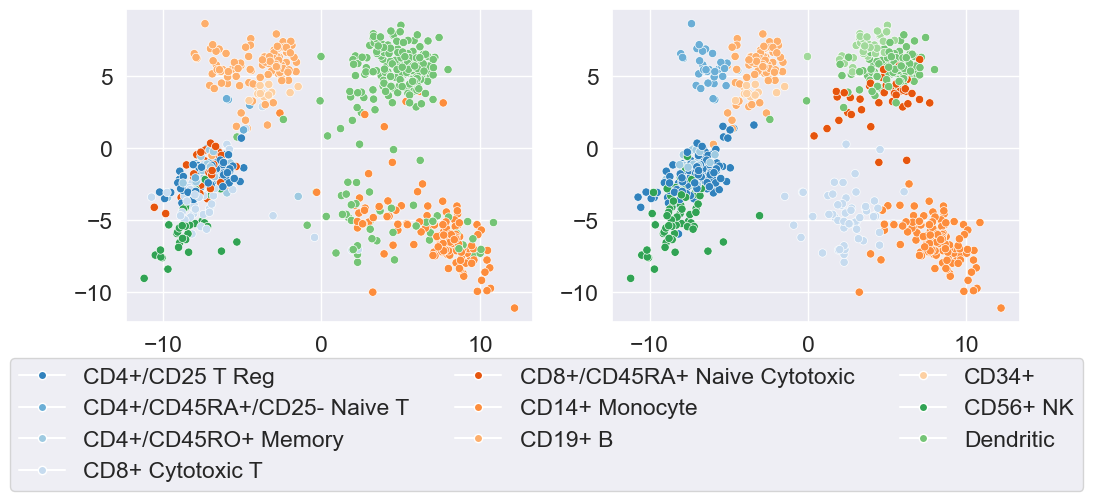

In [15]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import sys
sys.path.append('../')
from clim.utils.utils import match_labels

palette = sns.color_palette("tab20c", n_colors=20)

fig, ax = plt.subplots(1,2, figsize=(10, 4))
sns.set_theme(font_scale=1.5)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:, 1], hue=adata.obs['bulk_labels'], palette=palette, ax=ax[0], legend=False)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, adata.obs['louvain'].values.astype(int).tolist()), palette=palette, ax=ax[1], legend=False)
cats = pd.Categorical(adata.obs['bulk_labels']).categories

handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=palette[i], markersize=6, label=cat)
    for i, cat in enumerate(cats)
]

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=3,   # or adjust (e.g. 4)
    bbox_to_anchor=(0.5, -0.3)
)
plt.tight_layout()

/var/folders/r4/_v5hj9j14b53twvkrltmh9vh0000gn/T/ipykernel_81340/2644920380.py:14: UserWarning: The palette list has more values (10) than needed (1), which may not be intended.
  sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hue_val,palette=palette, ax=ax[i+1],legend=False)


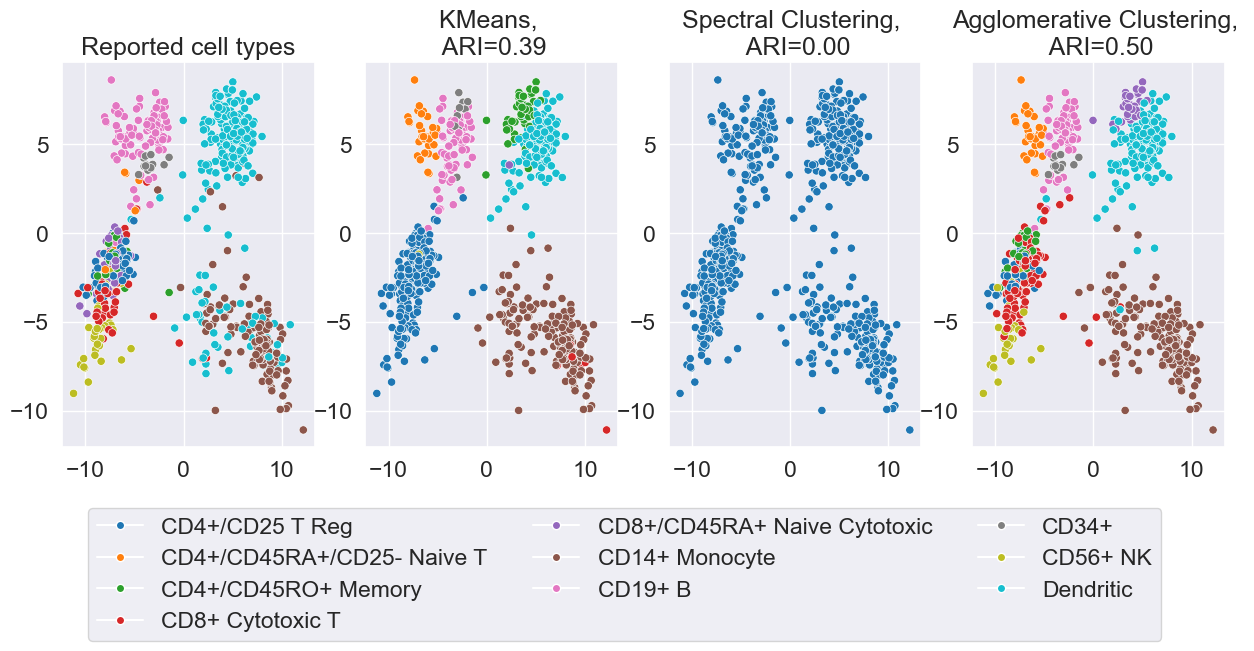

In [16]:
from clim.utils.utils import match_labels
from sklearn.metrics import adjusted_rand_score
fig, ax = plt.subplots(1,4, figsize=(15,5))
sns.set_theme(font_scale=1.5)
method = ['KMeans', 'Spectral Clustering', 'Agglomerative Clustering' ]
palette = sns.color_palette("tab10", n_colors=10)
km_labels = match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, km_labels)
sp_labels = match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, sp_labels)
ag_labels = match_labels(pd.Categorical(adata.obs['bulk_labels']).codes, ag_labels)
hue_list = [km_labels, sp_labels, ag_labels]
sns.scatterplot(x=X_pca[:,0], y=X_pca[:, 1], hue=adata.obs['bulk_labels'],palette=palette, ax=ax[0], legend=False)
ax[0].set_title("Reported cell types")
for i, hue_val in enumerate(hue_list):
    sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=hue_val,palette=palette, ax=ax[i+1],legend=False)
    ax[i+1].set_title(f'{method[i]}, \n ARI={adjusted_rand_score(pd.Categorical(adata.obs["bulk_labels"]).codes, hue_list[i]):.2f}')

from matplotlib.lines import Line2D

cats = pd.Categorical(adata.obs['bulk_labels']).categories

handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=palette[i], markersize=6, label=cat)
    for i, cat in enumerate(cats)
]

fig.legend(
    handles=handles,
    loc='lower center',
    ncol=3,   # or adjust (e.g. 4)
    bbox_to_anchor=(0.5, -0.3)
)

# Feature Importance scores

In [17]:
print('K=',len(adata.obs.bulk_labels.unique()))

K= 10


### Global Importance Scores

In [9]:
K = 10
km = KMeans(n_clusters=K)

In [11]:
X_pca = PCA(n_components=2).fit_transform(X)

In [12]:
N_JOBS = 8
print('KMeans based methods')
pbfi = PBFI(X, km)
lrp = LRP_score(np.array(X, dtype=float), K=K)

print('Permutation based methods')
perm_feat = feature_imp_cluster(km, X)['featureImp'].values


print('LOCO silhouette')
silhouette_km = LOCO_silhouette(km, X)


KMeans based methods
Permutation based methods
LOCO silhouette


In [ ]:
# shap_vals = c_SHAP(X=X, K=K, method='perm', X_reference=X).get_model_wide_importance()
## cSHAP is very slow to run

In [13]:
df = pd.DataFrame({'pbfi':pbfi, 'lrp':lrp, 'perm_km':perm_feat, 'feature':np.arange(X.shape[1])})

In [14]:
df.head()

,pbfi,lrp,perm_km,feature
0,0.001124,0.008004,0.000000,0
1,0.000308,0.000436,0.000000,1
2,0.000837,0.001247,0.000143,2
3,0.000603,0.002834,0.000000,3
4,0.000909,0.000741,0.000000,4


In [15]:
model = AgglomerativeClustering(n_clusters=K)

In [16]:
B = 5000 
B_ramp = 1000
alpha_N = 0.2
alpha_M = 0.2
N, p = X.shape


In [32]:
print("---- Cluster LOCOMP ----")
par = {"n_jobs_features":5,
   "backend":"loky",
   "prefer":"processes",
   "verbose":True,
  }

g = ClusterLOCOMP(base_clusterer = model, K=K, B=B)
g.fit(X, standardize=False, alpha_N = alpha_N, alpha_M = alpha_M, parallel=par)

---- Cluster LOCOMP ----
---------- Generate minipatches ------------
---------- Minipatch clustering ------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 4696 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    2.2s finished


---------- Minipatch reference ------------
---------- Minipatch training ------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 3824 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 5000 out of 5000 | elapsed:    5.0s finished


In [ ]:
cloc_out = g.score(hinge_error)
df['cloc_raw'] = cloc_out['delta']

In [24]:
df.head()

,pbfi,lrp,perm_km,feature,cloc_raw
0,0.001124,0.008004,0.000000,0,-0.000157
1,0.000308,0.000436,0.000000,1,-0.000196
2,0.000837,0.001247,0.000143,2,0.000004
3,0.000603,0.002834,0.000000,3,-0.000465
4,0.000909,0.000741,0.000000,4,0.000726


In [25]:
from clim.minipatches.rampart import *
print("---- Cluster LOCO RAMPART ----")
gen_fn = ClusterLOCO_RAMPART(
    base_clusterer=model,
    K=K,
    error_metric=hinge_error,
    parallel_MP=True,
    parallel={"n_jobs_features": 5, "backend": "loky", "prefer": "processes", "verbose": 0},
    standardize=False,
    alpha_N = 0.2,
    alpha_M = 0.2
)
out = RAMPART(
    X,
    generalizability_fn=gen_fn,
    B=B_ramp,
    ranking_fn=transform_scores_to_ranking,
    top_k=100,
    gen_kwargs={},
)

p = X.shape[1]
rampart_raw = np.zeros(p)
rampart_raw[out["selected_indices"]] = out["selected_scores"]
df['rampart_raw']=rampart_raw

---- Cluster LOCO RAMPART ----
---------- Generate minipatches ------------
---------- Minipatch clustering ------------
---------- Minipatch reference ------------
---------- Minipatch training ------------


765it [00:10, 71.06it/s]


[RAMPART] round 1/3: |C_t|=765 → |C_2|=383 (best feat=487, score=0.006461)
---------- Generate minipatches ------------
---------- Minipatch clustering ------------
---------- Minipatch reference ------------
---------- Minipatch training ------------


383it [00:04, 84.30it/s]


[RAMPART] round 2/3: |C_t|=383 → |C_3|=192 (best feat=239, score=0.006216)
---------- Generate minipatches ------------
---------- Minipatch clustering ------------
---------- Minipatch reference ------------
---------- Minipatch training ------------


192it [00:02, 93.49it/s]


[RAMPART] round 3/3: |C_t|=192 → |C_4|=96 (best feat=487, score=0.006197)
---------- Generate minipatches ------------
---------- Minipatch clustering ------------
---------- Minipatch reference ------------
---------- Minipatch training ------------


96it [00:00, 108.40it/s]


In [ ]:
print("---- impacc ----")
g = GlobalStability_MP(X, model, n_clusters=K)
impacc_res = g.impacc(X.T, K=K)
impacc = impacc_res["feature_importance"]

df['impacc'] = impacc

In [30]:
df.to_csv('../paper_figures/data/PBMC68k_FI_score_Global_K10.csv')

### Cluster-specific LOCO

In [ ]:
print("---- Cluster LOCOMP ----")
par = {"n_jobs_features":5,
   "backend":"loky",
   "prefer":"processes",
   "verbose":True,
  }

g = ClusterLOCOMP(base_clusterer = model, K=K, B=B)
g.fit(X, standardize=False, alpha_N = alpha_N, alpha_M = alpha_M, parallel=par)

In [33]:
cloc_out_cluster_wise = g.score(hinge_error, agg='by_clusters')

765it [04:30,  2.83it/s]
